![Clase aprendizaje no supervisado](https://raw.githubusercontent.com/MECA4605-Aprendizaje-no-supervisado/taller_4/main/figs/taller-meca-aprendizaje%20no%20supervisado_banner%201169%20x%20200%20px%20-05.png)

# Caso-taller: Identificando  Burger Master con MMG

El Burger Master es un evento creado en el 2016 por el *influencer* Tulio Zuluaga, más conocido en redes como Tulio recomienda, el cual busca que por una semana las hamburgueserías de cada ciudad ofrezcan su mejor producto a un precio reducido.

El evento ha venido creciendo y en el 2022 se extendió por 21 ciudades de Colombia para las cuales se estimó que se vendieron más de dos millones de hamburguesas. El objetivo del presente caso-taller  es identificar los puntos calientes de hamburgueserías  que compitieron en  la ciudad de Bogotá aplicando el Modelo de Mezclas Gaussianas.

## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Desarrollo

### 1. Carga de datos  

En la carpeta `data` se encuentra el archivo `burger_master.xlsx` para la ciudad de Bogotá, cargue estos datos en su *cuaderno* y reporte brevemente el contenido de la base.

In [1]:
# Configuración del entorno
import pandas as pd
import numpy as np
from pathlib import Path
!git clone https://github.com/camto-24/taller_4_Aprendizaje_no_supervisado.git

# Cargar archivo de Excel
ruta_archivo = Path("taller_4_Aprendizaje_no_supervisado/data/burger_master.xlsx")

# Ver las primeras fila
burger_master = pd.read_excel(ruta_archivo)

burger_master.head()

Cloning into 'taller_4_Aprendizaje_no_supervisado'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 44 (delta 22), reused 15 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 1.49 MiB | 11.50 MiB/s, done.
Resolving deltas: 100% (22/22), done.


,Restaurante,Dirección,Descripción,Latitud,Longitud
0,MAIKKI,Cra 75 # 24D – 48,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.668833,-74.116828
1,MAIKKI,Calle 119 # 11A – 24,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.698395,-74.036585
2,MAIKKI,Cra 47A # 98 – 47,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.686401,-74.060144
3,FRENCHEESE,Calle 51 #22-55,"<p>Presentamos «La French Master», inspirada e...",4.639514,-74.073545
4,FRENCHEESE,Calle 80 #14-41,"<p>Presentamos «La French Master», inspirada e...",4.666147,-74.056758


In [2]:
#Información general de la base
burger_master.info()
burger_master.shape
burger_master.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Restaurante  137 non-null    object 
 1   Dirección    137 non-null    object 
 2   Descripción  137 non-null    object 
 3   Latitud      137 non-null    float64
 4   Longitud     137 non-null    float64
dtypes: float64(2), object(3)
memory usage: 5.5+ KB


Index(['Restaurante', 'Dirección', 'Descripción', 'Latitud', 'Longitud'], dtype='object')

In [3]:
#Estadísticas descriptivas
data = burger_master.copy()

# Definir columnas
col_nombre = "Restaurante"
col_direccion = "Dirección"
col_descripcion = "Descripción"
col_lat = "Latitud"
col_lon = "Longitud"

#Resumen de la base
resumen_general = pd.DataFrame({
    "Indicador": [
        "Total de registros",
        "Restaurantes únicos",
        "Direcciones únicas",
        "Registros con coordenadas completas",
        "Registros sin latitud",
        "Registros sin longitud",
        "Duplicados por restaurante y dirección"
    ],
    "Valor": [
        len(data),
        data[col_nombre].nunique(),
        data[col_direccion].nunique(),
        data[[col_lat, col_lon]].dropna().shape[0],
        data[col_lat].isna().sum(),
        data[col_lon].isna().sum(),
        data.duplicated(subset=[col_nombre, col_direccion]).sum()
    ]
})

resumen_general


,Indicador,Valor
0,Total de registros,137
1,Restaurantes únicos,63
2,Direcciones únicas,116
3,Registros con coordenadas completas,137
4,Registros sin latitud,0
5,Registros sin longitud,0
6,Duplicados por restaurante y dirección,21


La base de datos contiene 137 registros correspondientes a restaurantes participantes en el evento de competencia de hamburguesas. No obstante, al revisar la información se identifican 63 restaurantes únicos y 116 direcciones únicas, lo que sugiere que algunos restaurantes pueden aparecer más de una vez, posiblemente por contar con diferentes sedes, registros repetidos o variaciones en la forma de registrar el nombre del establecimiento.

En términos de calidad de la información geográfica los 137 registros cuentan con coordenadas completas. No se identifican valores faltantes en las columnas de Latitud ni Longitud, lo cual permite utilizar la totalidad de las observaciones para aplicar el modelo de mezclas gaussianas. Esto es importante porque el objetivo del ejercicio es identificar posibles puntos calientes de concentración de hamburgueserías participantes dentro de la ciudad.

También se identificaron 21 registros duplicados por restaurante y dirección. Este punto debe revisarse antes de aplicar el modelo, porque los duplicados pueden afectar la estimación de los clusters al darle mayor peso a ciertos puntos geográficos. Por esta razón, una decisión metodológica relevante será determinar si esos duplicados corresponden a registros verdaderamente repetidos que deben eliminarse, o si representan participaciones válidas que deben mantenerse en la base.

En conjunto, las estadísticas descriptivas muestran que la base tiene una cobertura geográfica completa y suficiente para realizar un análisis de concentración espacial.

### 2.  Visualizando los datos

Visualice la ubicación de cada restaurante en un mapa interactivo. Añada un marcador para cada restaurante y la posibilidad de encontrar la descripción de la hamburguesa ofrecida en un pop-up. (Note que la columna Descripción contiene otra información adicional).

In [4]:
#Configuración del entorno
!pip install folium
import folium
from html import escape
from bs4 import BeautifulSoup

In [5]:
# Copia de la base
mapa = burger_master.copy()

# Asegurar que las coordenadas sean numéricas
mapa["Latitud"] = pd.to_numeric(mapa["Latitud"], errors="coerce")
mapa["Longitud"] = pd.to_numeric(mapa["Longitud"], errors="coerce")

# Eliminar registros sin coordenadas, si existieran
mapa = mapa.dropna(subset=["Latitud", "Longitud"])

# Función para limpiar la descripción
def limpiar_html(texto):
    if pd.isna(texto):
        return ""

    soup = BeautifulSoup(str(texto), "html.parser")

    # Convertir saltos <br> en saltos de línea
    for br in soup.find_all("br"):
        br.replace_with("\n")

    # Extraer solo el texto limpio
    texto_limpio = soup.get_text()

    # Limpiar espacios innecesarios
    texto_limpio = "\n".join(
        linea.strip() for linea in texto_limpio.split("\n") if linea.strip()
    )

    return texto_limpio

# Crear el mapa centrado en el promedio de coordenadas
centro_mapa = [mapa["Latitud"].mean(), mapa["Longitud"].mean()]

mapa_burgers = folium.Map(
    location=centro_mapa,
    zoom_start=12,
    tiles="OpenStreetMap"
)

# Agregar marcadores
for _, row in mapa.iterrows():
    restaurante = escape(str(row["Restaurante"]))
    direccion = escape(str(row["Dirección"]))
    descripcion_limpia = limpiar_html(row["Descripción"])

    # Escapar el texto limpio para evitar problemas, pero mantener saltos de línea
    descripcion_limpia = escape(descripcion_limpia).replace("\n", "<br>")

    popup_html = f"""
    <div style="width: 300px; font-family: Arial; font-size: 13px; line-height: 1.4;">
        <h4 style="margin-bottom: 6px;">{restaurante}</h4>
        <p style="margin: 0 0 8px 0;"><b>Dirección:</b> {escape(str(direccion))}</p>
        <p style="margin: 0 0 5px 0;"><b>Descripción de la hamburguesa:</b></p>
        <p style="margin: 0;">{descripcion_limpia}</p>
    </div>
    """

    folium.Marker(
        location=[row["Latitud"], row["Longitud"]],
        popup=folium.Popup(popup_html, max_width=350),
        tooltip=restaurante
    ).add_to(mapa_burgers)

mapa_burgers

Para visualizar la distribución espacial de los restaurantes participantes, se construyó un mapa interactivo a partir de las columnas de Latitud y Longitud de la base de datos. Primero, se verificó que las coordenadas estuvieran en formato numérico y se eliminaron posibles registros sin ubicación geográfica. Posteriormente, se creó un mapa centrado en el promedio de las coordenadas disponibles y se añadió un marcador para cada restaurante participante. Cada marcador incluye un popup con el nombre del restaurante, la dirección y la descripción de la hamburguesa ofrecida durante el evento, lo que permite explorar la información de cada punto de manera individual.

A partir de esta visualización, se observa que los restaurantes competidores no se distribuyen de manera homogénea en toda la ciudad. Por el contrario, existe una mayor concentración hacia la zona oriental y nororiental de Bogotá, especialmente en localidades como Chapinero, Teusaquillo, Santa Fe y Usaquén, donde se identifica una presencia más densa de restaurantes participantes. Esta concentración puede estar asociada con zonas de mayor actividad gastronómica, comercial y de entretenimiento, así como con sectores donde existe una mayor oferta de restaurantes especializados.

En contraste, hacia el sur de la ciudad se evidencia una menor participación. Localidades como Bosa, Ciudad Bolívar, Rafael Uribe Uribe y San Cristóbal presentan pocos o ningún registro visible de restaurantes competidores en el mapa. Esto sugiere una posible concentración del evento en zonas con mayor actividad comercial o gastronómica formal, dejando por fuera sectores del sur de la ciudad donde la oferta participante parece ser considerablemente menor.

También se observa una ausencia relativa de restaurantes hacia algunas zonas del noroccidente de Bogotá. Sin embargo, resulta interesante que sí aparecen registros en municipios aledaños como Chía y Cajicá, lo cual muestra que el evento no se limita estrictamente al perímetro urbano de Bogotá. Aun así, otros municipios cercanos como Cota no presentan registros visibles, lo que evidencia que la participación en municipios vecinos también es desigual y no depende únicamente de la cercanía geográfica con la ciudad.

En conjunto, el mapa interactivo permite identificar visualmente posibles puntos calientes de participación antes de aplicar el modelo de mezclas gaussianas. Los hallazgos preliminares sugieren que la competencia tuvo una mayor presencia en zonas del centro, oriente y norte de la ciudad, mientras que el sur y ciertas áreas periféricas presentan una menor representación.

### 3.  Análisis de puntos calientes

Aplique el modelo de Mezclas Gaussianas para buscar clusters de restaurantes en Bogotá, mencione qué estructura de covarianza usó y explique por qué. Escoja el número óptimo de componentes, explicando el procedimiento y justificando su elección.

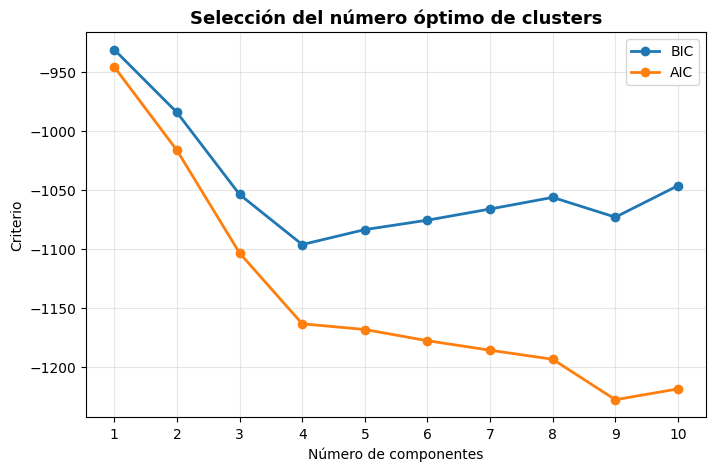

Número óptimo de componentes: 4


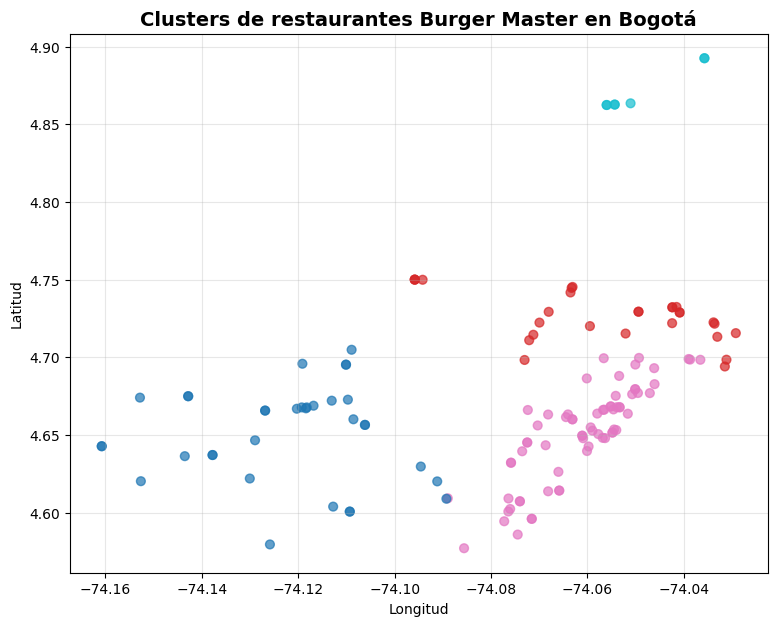

In [9]:
# Librerías
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# Copia de la base
gmm_data = burger_master.copy()

# Coordenadas
X = gmm_data[["Latitud", "Longitud"]].dropna().values

### Selección del número óptimo de clusters

# Número de componentes a evaluar
componentes = range(1, 11)

# Guardar resultados
bic_scores = []
aic_scores = []

# Ajustar modelos
for k in componentes:

    modelo = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=123
    )

    modelo.fit(X)

    bic_scores.append(modelo.bic(X))
    aic_scores.append(modelo.aic(X))

# Gráfica BIC y AIC

plt.figure(figsize=(8,5))

plt.plot(
    componentes,
    bic_scores,
    marker="o",
    linewidth=2,
    label="BIC"
)

plt.plot(
    componentes,
    aic_scores,
    marker="o",
    linewidth=2,
    label="AIC"
)

plt.xlabel("Número de componentes")
plt.ylabel("Criterio")
plt.title(
    "Selección del número óptimo de clusters",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(componentes)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

### Mejor modelo

# Número óptimo según BIC
k_optimo = componentes[np.argmin(bic_scores)]

print("Número óptimo de componentes:", k_optimo)

# Modelo final
gmm_final = GaussianMixture(
    n_components=k_optimo,
    covariance_type="full",
    random_state=123
)

gmm_final.fit(X)

# Predicción de clusters
clusters = gmm_final.predict(X)

# Agregar cluster a la base
gmm_data = gmm_data.dropna(
    subset=["Latitud", "Longitud"]
).copy()

gmm_data["cluster"] = clusters

### Visualización de clusters

plt.figure(figsize=(9,7))

plt.scatter(
    gmm_data["Longitud"],
    gmm_data["Latitud"],
    c=gmm_data["cluster"],
    cmap="tab10",
    alpha=0.7,
    s=40
)

plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.title(
    "Clusters de restaurantes Burger Master en Bogotá",
    fontsize=14,
    fontweight="bold"
)

plt.grid(alpha=0.3)

plt.show()

Para identificar el número óptimo de clusters se estimaron modelos de mezclas gaussianas con diferentes cantidades de componentes y se compararon los criterios AIC y BIC, los cuales permiten evaluar el balance entre ajuste y complejidad del modelo. Los resultados mostraron que ambos criterios disminuyen considerablemente hasta llegar a 4 componentes, indicando que este número captura adecuadamente la estructura espacial de los restaurantes Burger Master en Bogotá sin sobreajustar los datos. A partir de ese punto, la mejora es mucho menor e incluso el BIC comienza a aumentar, sugiriendo que agregar más clusters no aporta una representación significativamente mejor.

Con el modelo seleccionado se identificaron agrupaciones espaciales de restaurantes en zonas específicas de la ciudad, evidenciando que los establecimientos no están distribuidos de manera uniforme, sino concentrados en ciertos sectores urbanos con alta actividad comercial y demanda. En conclusión, el modelo de mezclas gaussianas permitió detectar patrones de localización y segmentar espacialmente los restaurantes de forma consistente y estadísticamente adecuada.

#### 3.1. Visualización de los resultados

Visualice las densidades estimadas por el  mejor modelo estimado en la sección anterior usando un mapa de calor interactivo, discuta los resultados.

In [10]:
# Instalar complemento
!pip install folium
from folium.plugins import HeatMap

# Datos para mapa de calor
heat_data = gmm_data[
    ["Latitud", "Longitud"]
].values.tolist()

# Crear mapa
centro_bogota = [
    gmm_data["Latitud"].mean(),
    gmm_data["Longitud"].mean()
]

mapa_calor = folium.Map(
    location=centro_bogota,
    zoom_start=11,
    tiles="CartoDB positron"
)

# Heatmap
HeatMap(
    heat_data,
    radius=18,
    blur=15,
    max_zoom=13
).add_to(mapa_calor)

# Mostrar mapa
mapa_calor

Para analizar la distribución espacial de los restaurantes participantes del Burger Master en Bogotá, se utilizó un mapa de calor construido con la librería `Folium` y el complemento `HeatMap`. A partir de la base `gmm_data`, se extrajeron las coordenadas de latitud y longitud de cada restaurante y se calculó el centro promedio para ubicar el mapa sobre la ciudad. Posteriormente, se generó un mapa base con el estilo `CartoDB positron` y se aplicó el mapa de calor con parámetros de radio y desenfoque que permiten visualizar de manera más clara las zonas de mayor concentración de establecimientos participantes. Esta técnica facilita identificar patrones espaciales y áreas donde la actividad gastronómica es más intensa.

El análisis del mapa muestra que los restaurantes del Burger Master se concentran principalmente en el corredor centro-oriental y norte de Bogotá, especialmente en localidades como Chapinero, Teusaquillo y Usaquén, donde aparecen las zonas de mayor intensidad en colores cálidos. También se observan algunos focos secundarios en sectores occidentales como Fontibón, mientras que en el sur de la ciudad la presencia es mucho más dispersa y reducida. Estos resultados sugieren que el evento tiene una mayor participación en áreas con alta actividad comercial, oferta gastronómica y capacidad de consumo, evidenciando una distribución desigual de los restaurantes dentro de la ciudad.

### 4. Comparación con KDE

Estime ahora las densidades usando KDE bivariado de la librería `statsmodels` con el anchos de banda dado por `cv_ml`. Muestre los resultados usando un mapa interactivo. Compare los resultados obtenidos por el "mejor" modelo encontrado via MMG.

In [8]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)